# 10. Sidewalk Width

Computes the remaining usable width of each sidewalk segment using:
- **BGT voetpad polygons** fetched from PDOK (the walkable area boundary)
- **Obstacle footprints** from LiDAR cluster centroids + areas (notebook 4 output)
- Optionally: panorama detections from notebook 9

Output: GeoJSON with per-segment `width_total_m`, `width_usable_m`, and accessibility category.

In [9]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.colors import Normalize

sys.path.insert(0, str(Path.cwd()))
import config
from utils.sidewalk_width import (
    fetch_voetpad_polygons, obstacle_footprints_from_inventory,
    compute_usable_width, width_to_geojson, width_category,
)


## Configuration

In [10]:
import json as _json_cfg
TILECODE   = config.SETUP_TILECODES[0]   # "120300_489300"
STEP_M     = 0.5                         # cross-section interval in metres
OBSTACLE_BUFFER_M = 0.15                 # extra radius around each footprint

# Use the actual LiDAR footprint polygon as the search bbox, with a buffer
# so voetpad polygons just outside the cloud boundary are also captured.
BBOX_BUFFER_M = 30.0
_bbox_path = config.BBOX_DIR / f"bbox_{TILECODE}.geojson"
if _bbox_path.exists():
    with open(_bbox_path) as _f:
        _gj = _json_cfg.load(_f)
    import numpy as _np_cfg
    _coords = _np_cfg.array(_gj["features"][0]["geometry"]["coordinates"][0])
    TILE_BBOX_RD = (
        float(_coords[:, 0].min()) - BBOX_BUFFER_M,
        float(_coords[:, 1].min()) - BBOX_BUFFER_M,
        float(_coords[:, 0].max()) + BBOX_BUFFER_M,
        float(_coords[:, 1].max()) + BBOX_BUFFER_M,
    )
else:
    parts = TILECODE.split("_")
    TILE_BBOX_RD = (float(parts[0]) - BBOX_BUFFER_M, float(parts[1]) - BBOX_BUFFER_M,
                    float(parts[0]) + 50 + BBOX_BUFFER_M, float(parts[1]) + 50 + BBOX_BUFFER_M)

print(f"Tile:  {TILECODE}")
print(f"Bbox:  {tuple(round(v) for v in TILE_BBOX_RD)}")


Tile:  120300_489300
Bbox:  (120270, 489270, 120430, 489430)


## Load BGT voetpad polygons

In [11]:
voetpad_cache = Path(f"data/input/bgt/voetpad_{TILECODE}.geojson")

if voetpad_cache.exists():
    voetpad_gdf = gpd.read_file(voetpad_cache).to_crs("EPSG:28992")
    print(f"Loaded {len(voetpad_gdf)} voetpad polygons from cache.")
else:
    print("Fetching voetpad polygons from PDOK…")
    voetpad_gdf = fetch_voetpad_polygons(TILE_BBOX_RD)
    if len(voetpad_gdf) > 0:
        voetpad_cache.parent.mkdir(parents=True, exist_ok=True)
        voetpad_gdf.to_file(str(voetpad_cache), driver="GeoJSON")
        print(f"Cached to {voetpad_cache}")

print(f"{len(voetpad_gdf)} voetpad polygon(s) found.")
if len(voetpad_gdf) > 0:
    total_area = voetpad_gdf.geometry.area.sum()
    print(f"Total voetpad area: {total_area:.1f} m²")


Loaded 39 voetpad polygons from cache.
39 voetpad polygon(s) found.
Total voetpad area: 12568.2 m²


## Load obstacle footprints from LiDAR clusters

In [12]:
from utils.labels import Labels

# Inventory path: top-level first (notebook 4 output), then tile subdirectory
inv_path = config.CLUSTERS_DIR / f"inventory_{TILECODE}.csv"
if not inv_path.exists():
    inv_path = config.CLUSTERS_DIR / TILECODE / f"inventory_{TILECODE}.csv"

if not inv_path.exists():
    print(f"No inventory found — run notebooks 3.5 and 4 first.")
    cluster_df = pd.DataFrame()
else:
    cluster_df = pd.read_csv(inv_path)
    _lbl_col = "final_label" if cluster_df.get("final_label", pd.Series()).notna().any() else "label"
    cluster_df["_lbl"] = cluster_df[_lbl_col].fillna(0).astype(int)
    print(f"Loaded {len(cluster_df)} clusters from {inv_path.name}")
    print(cluster_df["_lbl"].map(Labels.STR_DICT).value_counts().to_string())

obstacles_gdf = gpd.GeoDataFrame(
    columns=["cluster_id", "label", "geometry"], crs="EPSG:28992"
)
if len(cluster_df) > 0:
    obstacles_gdf = obstacle_footprints_from_inventory(
        cluster_df,
        clusters_dir=config.CLUSTERS_DIR / TILECODE,
        buffer_m=OBSTACLE_BUFFER_M,
    )
    print(f"\n{len(obstacles_gdf)} obstacle footprints built.")
    print("Labels:", {Labels.STR_DICT.get(int(k), str(k)): v
                      for k, v in obstacles_gdf["label"].value_counts().items()})


Loaded 57 clusters from inventory_120300_489300.csv
_lbl
Unknown            40
Tree               10
Car                 5
Streetlight         1
Large container     1

0 obstacle footprints built.
Labels: {}


## (Optional) Add panorama detections as additional obstacles

Panorama detections that had no matching LiDAR cluster are potential missed obstacles.

In [13]:
pano_det_path = config.CLUSTERS_DIR / TILECODE / f"panorama_detections_{TILECODE}.geojson"
if pano_det_path.exists():
    pano_gdf = gpd.read_file(pano_det_path).to_crs("EPSG:28992")
    # Buffer each detection point by 0.3m as footprint approximation
    pano_gdf["geometry"] = pano_gdf.geometry.buffer(0.3)
    pano_gdf["cluster_id"] = "pano_" + pano_gdf.index.astype(str)
    pano_gdf["label"] = pano_gdf.get("upsw_label", 0)

    extra = pano_gdf[["cluster_id", "label", "geometry"]]
    obstacles_gdf = gpd.GeoDataFrame(
        pd.concat([obstacles_gdf, extra], ignore_index=True),
        crs="EPSG:28992",
    )
    print(f"Added {len(pano_gdf)} panorama detections. Total obstacles: {len(obstacles_gdf)}")
else:
    print("No panorama detections file — using LiDAR obstacles only.")


Added 36 panorama detections. Total obstacles: 36


## Compute usable width

In [14]:
if len(voetpad_gdf) == 0:
    print("No voetpad polygons — cannot compute width. Try a different tile or increase TILE_BBOX_RD padding.")
else:
    print("Computing cross-sectional widths…")
    width_gdf = compute_usable_width(voetpad_gdf, obstacles_gdf, step_m=STEP_M)
    width_gdf["category"] = width_gdf["width_usable_m"].apply(width_category)
    print(f"Generated {len(width_gdf)} measurement segments.")
    print(width_gdf[["width_total_m", "width_usable_m", "category"]].describe())


Computing cross-sectional widths…
Generated 2512 measurement segments.
       width_total_m  width_usable_m
count    2512.000000     2512.000000
mean        4.619082        4.593078
std         2.489019        2.468405
min         1.368000        1.368000
25%         3.169750        3.169750
50%         3.797000        3.797000
75%         5.614000        5.531000
max        20.446000       20.446000


## Visualise

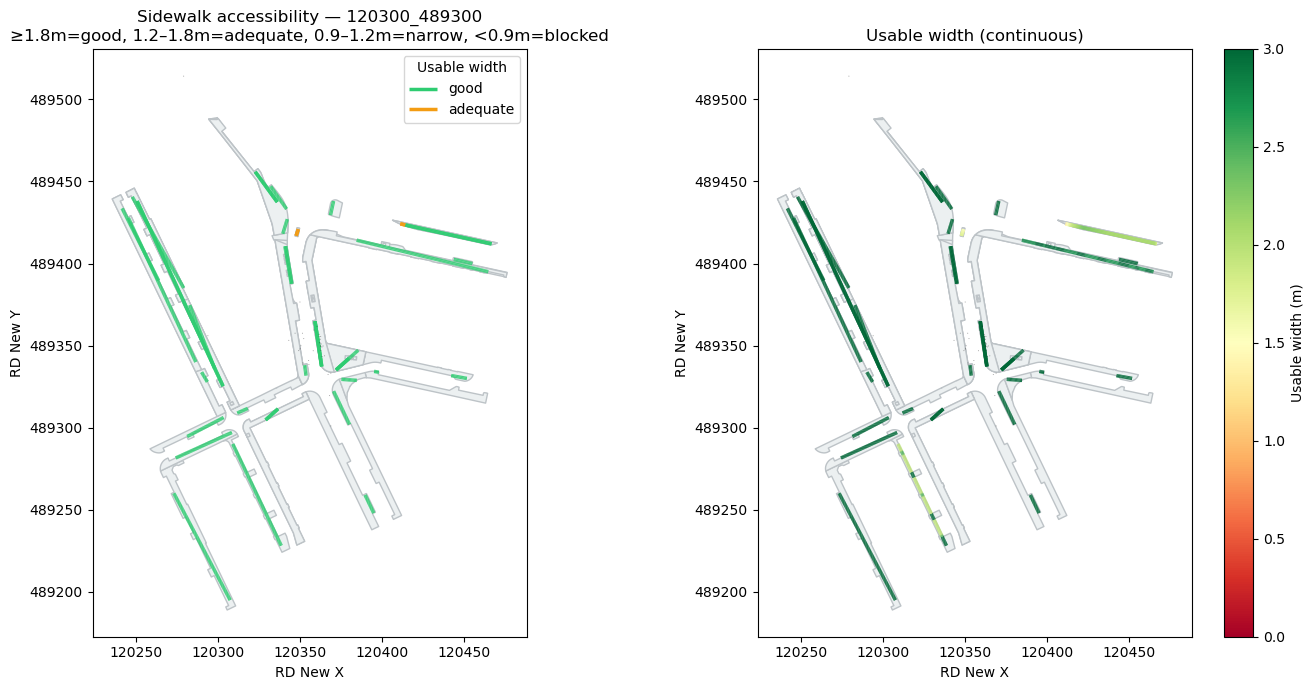

In [7]:
if len(voetpad_gdf) > 0 and len(width_gdf) > 0:
    CATEGORY_COLORS = {
        "good":     "#2ecc71",   # green
        "adequate": "#f39c12",   # orange
        "narrow":   "#e74c3c",   # red
        "blocked":  "#8e44ad",   # purple
        "unknown":  "#95a5a6",   # grey
    }

    fig, axes = plt.subplots(1, 2, figsize=(14, 7))

    # — Left: category map
    ax = axes[0]
    voetpad_gdf.plot(ax=ax, color="#ecf0f1", edgecolor="#bdc3c7", zorder=1)
    for cat, color in CATEGORY_COLORS.items():
        sub = width_gdf[width_gdf["category"] == cat]
        if len(sub) > 0:
            sub.plot(ax=ax, color=color, linewidth=2.5, label=cat, zorder=2)
    if len(obstacles_gdf) > 0:
        obstacles_gdf.plot(ax=ax, color="black", alpha=0.4, zorder=3)
    ax.set_aspect("equal")
    ax.legend(title="Usable width", loc="upper right")
    ax.set_title(f"Sidewalk accessibility — {TILECODE}\n"
                 f"≥1.8m=good, 1.2–1.8m=adequate, 0.9–1.2m=narrow, <0.9m=blocked")
    ax.set_xlabel("RD New X")
    ax.set_ylabel("RD New Y")

    # — Right: continuous usable width heatmap
    ax2 = axes[1]
    voetpad_gdf.plot(ax=ax2, color="#ecf0f1", edgecolor="#bdc3c7", zorder=1)
    norm = Normalize(vmin=0, vmax=3.0)
    cmap = cm.RdYlGn
    for _, row in width_gdf.iterrows():
        color = cmap(norm(row["width_usable_m"]))
        gpd.GeoDataFrame([row], crs="EPSG:28992").plot(
            ax=ax2, color=[color], linewidth=2.5, zorder=2
        )
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    plt.colorbar(sm, ax=ax2, label="Usable width (m)")
    if len(obstacles_gdf) > 0:
        obstacles_gdf.plot(ax=ax2, color="black", alpha=0.4, zorder=3)
    ax2.set_aspect("equal")
    ax2.set_title("Usable width (continuous)")
    ax2.set_xlabel("RD New X")
    ax2.set_ylabel("RD New Y")

    plt.tight_layout()
    plt.show()


## LiDAR DBSCAN clusters vs panorama detections

Side-by-side comparison of what each sensor source contributes to the sidewalk obstacle picture.
Left panel shows only LiDAR DBSCAN obstacles; right panel overlays the YOLO panorama detections.
Both are plotted on top of the BGT voetpad polygons so you can see which obstacles actually
affect passable width.

Panorama detections: 36
class_name
bicycle          17
car               7
chair             4
motorcycle        3
traffic light     1
fire hydrant      1
person            1
umbrella          1
potted plant      1

Matched pairs:        11
  Labels agree:       0
YOLO-only:            25
LiDAR-only obstacles: 33


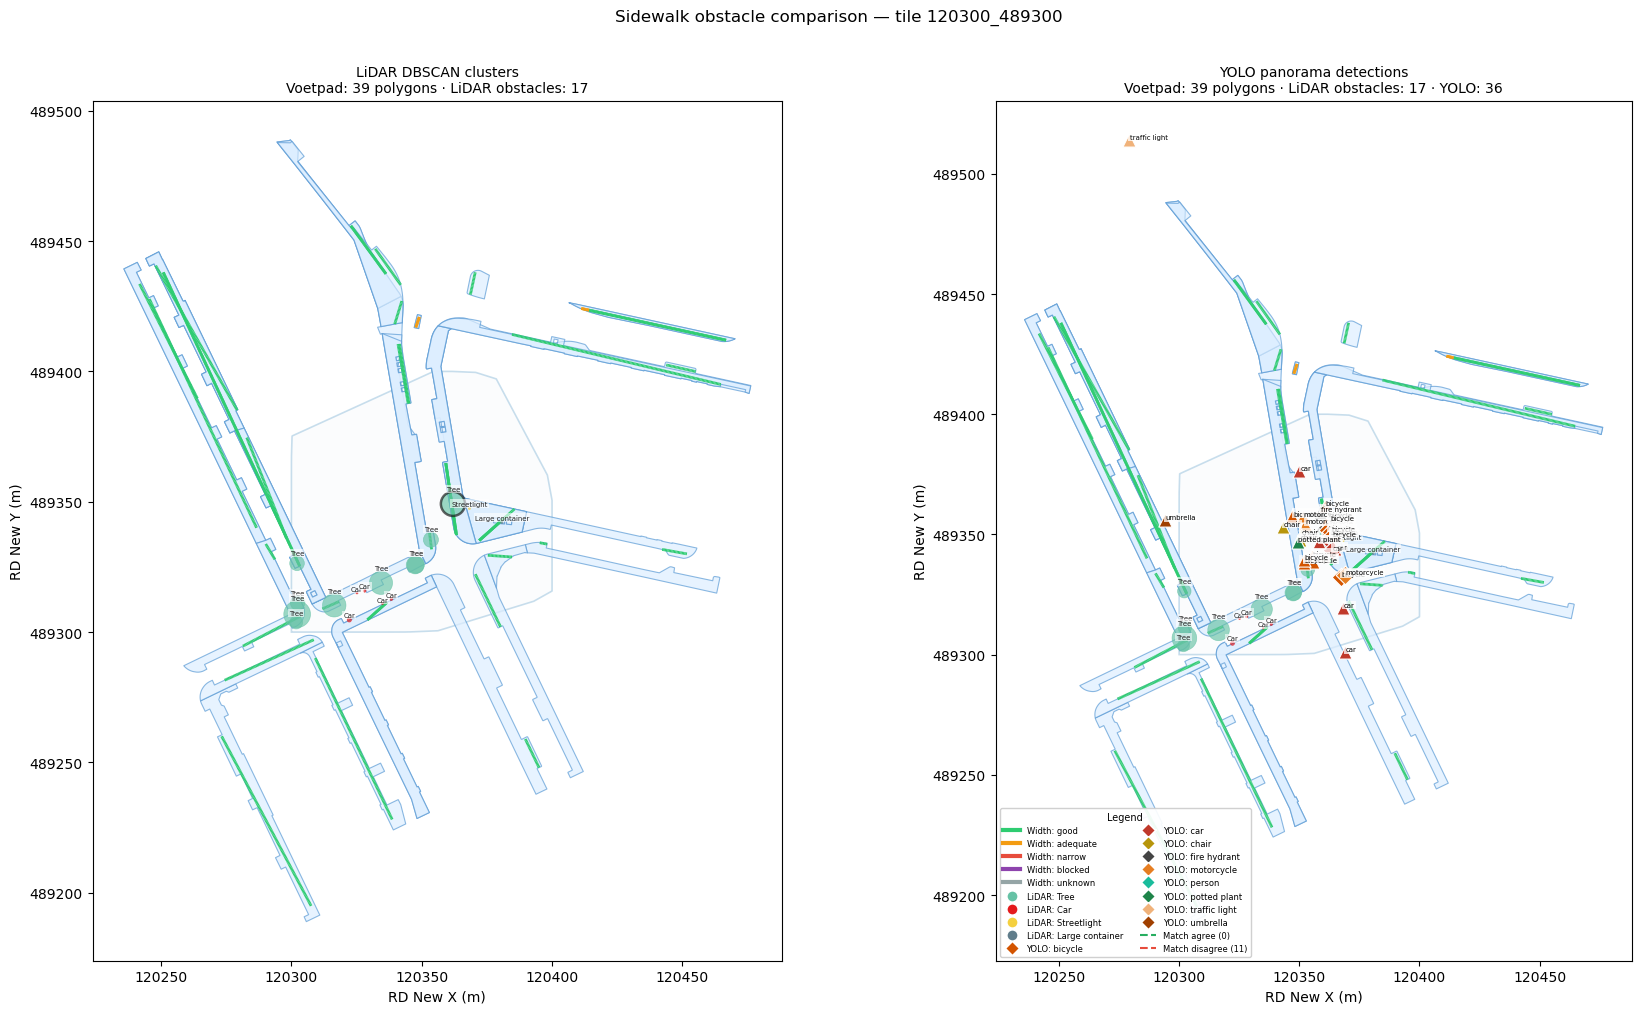


Obstacles on voetpad (intersect any voetpad polygon):
  LiDAR: 21/36 clusters on voetpad
  YOLO:  23/36 detections on/near voetpad


/var/folders/xm/kv_h3z3j6113q49b_8lb9xdh0000gn/T/ipykernel_18468/512118353.py:170: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  _vunion = voetpad_gdf.geometry.unary_union


  YOLO-only on voetpad (potential LiDAR miss): 14


In [15]:
import json as _jc
import numpy as _npc
import geopandas as gpd
from shapely.geometry import Point as _SPt
from matplotlib.patches import Circle as _MCircle, Polygon as _MPoly
from matplotlib.lines import Line2D

# ── Load panorama detections ──────────────────────────────────────────────────
_det_path = config.CLUSTERS_DIR / TILECODE / f"panorama_detections_{TILECODE}.geojson"
if _det_path.exists():
    pano_pts = gpd.read_file(_det_path).to_crs("EPSG:28992")
    print(f"Panorama detections: {len(pano_pts)}")
    print(pano_pts["class_name"].value_counts().to_string())
else:
    pano_pts = gpd.GeoDataFrame(columns=["class_name", "confidence", "geometry"],
                                 crs="EPSG:28992")
    print("No panorama detections — run notebook 9 steps C-F first.")

# ── Spatial match: YOLO detection ↔ nearest LiDAR cluster ───────────────────
MATCH_R = 3.0
from utils.detection import COCO_TO_UPSW

_matched_y, _matched_c, _match_pairs = set(), set(), []
if len(pano_pts) > 0 and len(cluster_df) > 0:
    for yi, yrow in pano_pts.iterrows():
        px, py = yrow.geometry.x, yrow.geometry.y
        dists  = _npc.hypot(cluster_df["centroid_x"].values - px,
                            cluster_df["centroid_y"].values - py)
        bi = int(_npc.argmin(dists));  bd = float(dists[bi])
        if bd <= MATCH_R:
            clbl   = int(cluster_df.iloc[bi]["_lbl"])
            yupsw  = COCO_TO_UPSW.get(yrow["class_name"], -1)
            _match_pairs.append((yi, bi, bd, yrow["class_name"], clbl, yupsw == clbl))
            _matched_y.add(yi);  _matched_c.add(bi)

print(f"\nMatched pairs:        {len(_match_pairs)}")
print(f"  Labels agree:       {sum(r[5] for r in _match_pairs)}")
print(f"YOLO-only:            {len(pano_pts) - len(_matched_y)}")
print(f"LiDAR-only obstacles: {len(obstacles_gdf) - len(_matched_c)}")

# ── Colour palettes ───────────────────────────────────────────────────────────
LIDAR_C = {
    0:"#cccccc", 30:"#66c2a5", 39:"#99d8c9", 40:"#e41a1c",
    44:"#ff7f00", 45:"#fdbf6f", 60:"#f4d03f", 61:"#f0e442",
    62:"#56b4e9", 65:"#984ea3", 80:"#795548", 81:"#a1887f",
    83:"#607d8b", 85:"#009e73", 88:"#d55e00", 91:"#e0aaff",
}
YOLO_C = {
    "car":"#c0392b",    "truck":"#922b21",      "bus":"#884ea0",
    "bicycle":"#d35400","motorcycle":"#e67e22",  "person":"#1abc9c",
    "bench":"#7d6608",  "chair":"#b7950b",       "umbrella":"#a04000",
    "potted plant":"#1e8449","traffic light":"#f0b27a","stop sign":"#1a5276",
    "parking meter":"#117a65",
}

# ── Load tile polygon ─────────────────────────────────────────────────────────
def _tile_patch(ax, alpha=0.25):
    _bp = config.BBOX_DIR / f"bbox_{TILECODE}.geojson"
    if _bp.exists():
        with open(_bp) as _ff:
            _g = _jc.load(_ff)
        _xy = _npc.array(_g["features"][0]["geometry"]["coordinates"][0])
        ax.add_patch(_MPoly(_xy, closed=True, facecolor="#f0f4f8",
                            edgecolor="#2980b9", lw=1.2, alpha=alpha, zorder=0))

# ── Figure: 1×2 side-by-side ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 10))

for col, (ax, title, show_yolo) in enumerate(zip(
    axes,
    ["LiDAR DBSCAN clusters", "YOLO panorama detections"],
    [False, True],
)):
    _tile_patch(ax)

    # Voetpad polygons
    if len(voetpad_gdf) > 0:
        voetpad_gdf.plot(ax=ax, color="#ddeeff", edgecolor="#5b9bd5",
                         linewidth=0.8, alpha=0.7, zorder=1)

    # Usable width lines
    if "width_gdf" in dir() and len(width_gdf) > 0:
        CAT_C = {"good":"#2ecc71","adequate":"#f39c12",
                 "narrow":"#e74c3c","blocked":"#8e44ad","unknown":"#95a5a6"}
        for cat, cc in CAT_C.items():
            sub = width_gdf[width_gdf["category"] == cat]
            if len(sub):
                sub.plot(ax=ax, color=cc, linewidth=2.0, zorder=2, label=cat)

    # LiDAR cluster footprints (always shown)
    if len(obstacles_gdf) > 0:
        for ci, crow in cluster_df.iterrows():
            lbl = crow["_lbl"]
            if lbl == 0:
                continue   # skip unknown
            cx, cy = crow["centroid_x"], crow["centroid_y"]
            r = min(max(_npc.sqrt(max(crow["area_m2"], 0.1) / _npc.pi), 0.3), 8.0)
            matched = ci in _matched_c
            ax.add_patch(_MCircle(
                (cx, cy), r,
                facecolor=LIDAR_C.get(lbl, "#aaa"),
                edgecolor="#111" if matched else LIDAR_C.get(lbl, "#aaa"),
                linewidth=1.8 if matched else 0.5, alpha=0.65, zorder=4,
            ))
            ax.text(cx, cy + r + 0.4, Labels.STR_DICT.get(lbl, str(lbl)),
                    fontsize=5, ha="center", color="#222", zorder=5,
                    bbox=dict(facecolor="white", alpha=0.6, edgecolor="none", pad=0.8))

    # YOLO panorama detections (right panel only)
    if show_yolo and len(pano_pts) > 0:
        for yi, yrow in pano_pts.iterrows():
            px, py = yrow.geometry.x, yrow.geometry.y
            cls  = yrow["class_name"]
            yc   = YOLO_C.get(cls, "#444")
            is_m = yi in _matched_y
            ax.scatter(px, py, s=90, color=yc, zorder=9,
                       marker="D" if is_m else "^",
                       edgecolor="white", linewidth=0.8)
            ax.text(px + 0.3, py + 0.3, cls, fontsize=5, zorder=10,
                    bbox=dict(facecolor="white", alpha=0.75, edgecolor="none", pad=1))

        # Match lines
        for yi, ci, dist, ycls, clbl, ok in _match_pairs:
            yr = pano_pts.loc[yi];  cr = cluster_df.iloc[ci]
            ax.plot([yr.geometry.x, cr["centroid_x"]],
                    [yr.geometry.y, cr["centroid_y"]],
                    color="#27ae60" if ok else "#e74c3c",
                    alpha=0.5, lw=0.9, linestyle="--", zorder=6)

    ax.autoscale(); ax.set_aspect("equal")
    ax.set_xlabel("RD New X (m)"); ax.set_ylabel("RD New Y (m)")
    n_lidar = int((cluster_df["_lbl"] != 0).sum()) if len(cluster_df) else 0
    n_yolo  = len(pano_pts) if show_yolo else 0
    ax.set_title(f"{title}\n"
                 f"Voetpad: {len(voetpad_gdf)} polygons · "
                 f"LiDAR obstacles: {n_lidar}"
                 + (f" · YOLO: {n_yolo}" if show_yolo else ""),
                 fontsize=10)

# Shared legend
_cat_c = {"good":"#2ecc71","adequate":"#f39c12","narrow":"#e74c3c",
          "blocked":"#8e44ad","unknown":"#95a5a6"}
_handles = [
    *[Line2D([0],[0], color=c, lw=3, label=f"Width: {k}") for k, c in _cat_c.items()],
    *[Line2D([0],[0], marker="o", color="w", markerfacecolor=LIDAR_C.get(l,"#aaa"),
              markersize=8, label=f"LiDAR: {Labels.STR_DICT.get(l, str(l))}")
      for l in sorted(cluster_df["_lbl"].unique()) if l != 0],
]
if len(pano_pts) > 0:
    _handles += [
        Line2D([0],[0], marker="D", color="w",
               markerfacecolor=YOLO_C.get(cls,"#444"), markersize=7,
               label=f"YOLO: {cls}")
        for cls in sorted(pano_pts["class_name"].unique())
    ]
    _handles += [
        Line2D([0],[0], ls="--", color="#27ae60", label=f"Match agree ({sum(r[5] for r in _match_pairs)})"),
        Line2D([0],[0], ls="--", color="#e74c3c", label=f"Match disagree ({sum(not r[5] for r in _match_pairs)})"),
    ]

axes[1].legend(handles=_handles, fontsize=6, loc="lower left",
               framealpha=0.92, ncol=2, title="Legend", title_fontsize=7)
plt.suptitle(f"Sidewalk obstacle comparison — tile {TILECODE}", fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

# ── Summary table ─────────────────────────────────────────────────────────────
print("\nObstacles on voetpad (intersect any voetpad polygon):")
if len(voetpad_gdf) > 0 and len(obstacles_gdf) > 0:
    _vunion = voetpad_gdf.geometry.unary_union
    _on_vp  = obstacles_gdf[obstacles_gdf.geometry.intersects(_vunion)]
    print(f"  LiDAR: {len(_on_vp)}/{len(obstacles_gdf)} clusters on voetpad")
    if len(pano_pts) > 0:
        _pano_on = pano_pts[pano_pts.geometry.intersects(_vunion.buffer(0.5))]
        print(f"  YOLO:  {len(_pano_on)}/{len(pano_pts)} detections on/near voetpad")
        _only_pano = [yi for yi in pano_pts.index
                      if yi not in _matched_y
                      and pano_pts.loc[yi].geometry.intersects(_vunion.buffer(0.5))]
        print(f"  YOLO-only on voetpad (potential LiDAR miss): {len(_only_pano)}")


## OSM sidewalk network with usable-width attribute

BGT `voetpad` polygons are geometrically accurate but miss segments where the BGT
maps the full street surface as `rijbaan` (carriageway) without a separate voetpad
record — common in older Amsterdam street blocks.

OpenStreetMap `highway=footway|pedestrian|path` ways give a **connected, routable
sidewalk network** that fills those gaps.  This section:
1. Downloads OSM pedestrian edges for the tile area with `osmnx`
2. For each edge: finds an overlapping BGT voetpad polygon → uses it as the precise
   boundary for cross-section measurements; if none exists uses a
   `default_half_width_m` buffer instead
3. Subtracts obstacle footprints using the same cross-section logic as above
4. Attaches `width_usable_m`, `width_usable_min_m`, and `category` per edge
5. Exports `osm_sidewalk_width_<TILECODE>.geojson`

Cached to data/input/bgt/osm_sidewalks_120300_489300.geojson
OSM edges: 4,  total length: 126 m
highway
footway    4

Computing usable width on OSM network …
Width computed for 4/4 edges.
  BGT polygon used:  1   (accurate total width)
  Default fallback:  3  (assumed 2.4 m total)


/var/folders/xm/kv_h3z3j6113q49b_8lb9xdh0000gn/T/ipykernel_18468/3694964988.py:54: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  _sub[~_sub["bgt_matched"]].plot(ax=ax, color=cc, linewidth=1.5,
/var/folders/xm/kv_h3z3j6113q49b_8lb9xdh0000gn/T/ipykernel_18468/3694964988.py:56: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  _sub[_sub["bgt_matched"]].plot(ax=ax, color=cc, linewidth=2.5,
/var/folders/xm/kv_h3z3j6113q49b_8lb9xdh0000gn/T/ipykernel_18468/3694964988.py:78: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax2.legend(fontsize=7, loc="upper right")


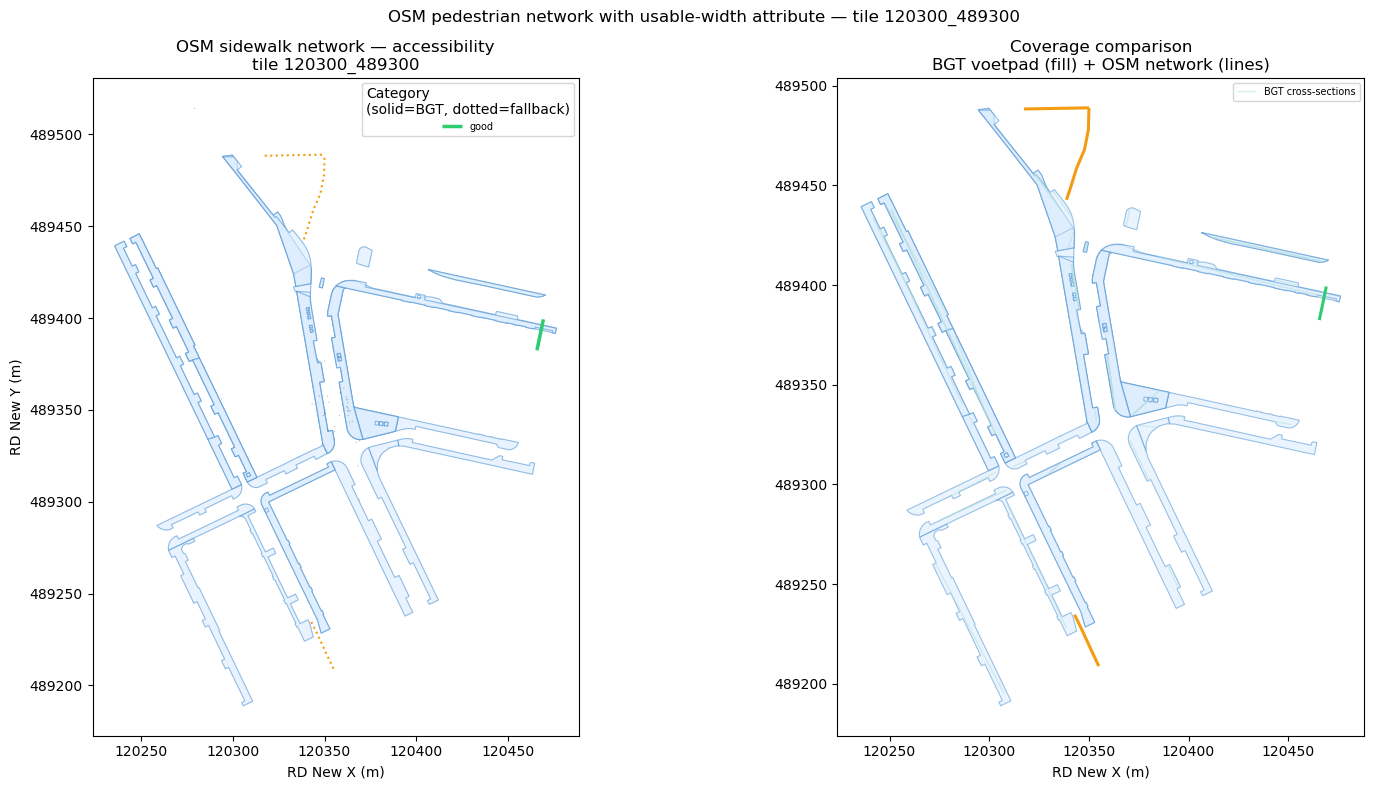


OSM edge category summary:
          n_edges  total_m  mean_usable_m  min_usable_m
category                                               
good            1    17.20          20.07          8.66
adequate        3   109.05           2.36          1.20

Total OSM sidewalk length: 126 m
Wheelchair accessible (≥0.9 m): 100.0%

Exported to data/output/clusters/120300_489300/osm_sidewalk_width_120300_489300.geojson


In [16]:
from utils.sidewalk_width import fetch_osm_sidewalks, compute_width_on_osm_network

OSM_DEFAULT_HALF_WIDTH_M = 1.2  # fallback half-width when no BGT polygon matches (2.4 m total)
OSM_STEP_M = 1.0                # cross-section sampling interval along OSM edges

_osm_cache = Path(f"data/input/bgt/osm_sidewalks_{TILECODE}.geojson")

if _osm_cache.exists():
    osm_edges = gpd.read_file(_osm_cache).to_crs("EPSG:28992")
    print(f"Loaded {len(osm_edges)} OSM edges from cache.")
else:
    print("Downloading OSM pedestrian network …")
    try:
        osm_edges = fetch_osm_sidewalks(TILE_BBOX_RD)
        _osm_cache.parent.mkdir(parents=True, exist_ok=True)
        osm_edges.to_file(str(_osm_cache), driver="GeoJSON")
        print(f"Cached to {_osm_cache}")
    except Exception as _e:
        print(f"OSM download failed: {_e}")
        osm_edges = gpd.GeoDataFrame()   # empty — no crs arg (geopandas ≥0.13 requires geometry column)

if len(osm_edges) == 0:
    print("No OSM edges — skipping width computation.")
else:
    print(f"OSM edges: {len(osm_edges)},  total length: {osm_edges.geometry.length.sum():.0f} m")
    print(osm_edges["highway"].explode().value_counts().to_string())

    print("\nComputing usable width on OSM network …")
    osm_width_gdf = compute_width_on_osm_network(
        osm_edges, voetpad_gdf, obstacles_gdf,
        step_m=OSM_STEP_M,
        default_half_width_m=OSM_DEFAULT_HALF_WIDTH_M,
    )
    n_bgt   = int(osm_width_gdf["bgt_matched"].sum()) if len(osm_width_gdf) else 0
    n_fall  = len(osm_width_gdf) - n_bgt
    print(f"Width computed for {len(osm_width_gdf)}/{len(osm_edges)} edges.")
    print(f"  BGT polygon used:  {n_bgt}   (accurate total width)")
    print(f"  Default fallback:  {n_fall}  (assumed {OSM_DEFAULT_HALF_WIDTH_M * 2:.1f} m total)")

    # ── Plot ──────────────────────────────────────────────────────────────────
    _CAT_C = {"good":"#2ecc71","adequate":"#f39c12",
               "narrow":"#e74c3c","blocked":"#8e44ad","unknown":"#95a5a6"}

    fig, axes = plt.subplots(1, 2, figsize=(16, 8), sharex=False, sharey=False)

    # Left: OSM edges coloured by accessibility category
    ax = axes[0]
    if len(voetpad_gdf) > 0:
        voetpad_gdf.plot(ax=ax, color="#ddeeff", edgecolor="#5b9bd5",
                          linewidth=0.8, alpha=0.65, zorder=1)
    for cat, cc in _CAT_C.items():
        _sub = osm_width_gdf[osm_width_gdf["category"] == cat]
        if len(_sub):
            _sub[~_sub["bgt_matched"]].plot(ax=ax, color=cc, linewidth=1.5,
                                             linestyle=":", zorder=3)
            _sub[_sub["bgt_matched"]].plot(ax=ax, color=cc, linewidth=2.5,
                                            linestyle="-", label=cat, zorder=3)
    if len(obstacles_gdf) > 0:
        obstacles_gdf.plot(ax=ax, color="black", alpha=0.35, zorder=4)
    ax.set_aspect("equal")
    ax.legend(title="Category\n(solid=BGT, dotted=fallback)", fontsize=7, loc="upper right")
    ax.set_title(f"OSM sidewalk network — accessibility\ntile {TILECODE}")
    ax.set_xlabel("RD New X (m)"); ax.set_ylabel("RD New Y (m)")

    # Right: coverage comparison — BGT voetpad polygons vs OSM network
    ax2 = axes[1]
    if len(voetpad_gdf) > 0:
        voetpad_gdf.plot(ax=ax2, color="#ddeeff", edgecolor="#5b9bd5",
                          linewidth=0.8, alpha=0.6, zorder=1, label="BGT voetpad polygon")
    if "width_gdf" in dir() and len(width_gdf) > 0:
        width_gdf.plot(ax=ax2, color="#b2dfdb", linewidth=1.0, alpha=0.5,
                        zorder=2, label="BGT cross-sections")
    for cat, cc in _CAT_C.items():
        _sub = osm_width_gdf[osm_width_gdf["category"] == cat]
        if len(_sub):
            _sub.plot(ax=ax2, color=cc, linewidth=2.2, zorder=3)
    ax2.set_aspect("equal")
    ax2.legend(fontsize=7, loc="upper right")
    ax2.set_title("Coverage comparison\nBGT voetpad (fill) + OSM network (lines)")
    ax2.set_xlabel("RD New X (m)")

    plt.suptitle(f"OSM pedestrian network with usable-width attribute — tile {TILECODE}", fontsize=12)
    plt.tight_layout()
    plt.show()

    # ── Summary ───────────────────────────────────────────────────────────────
    print("\nOSM edge category summary:")
    _smry = (osm_width_gdf
             .assign(_len=osm_width_gdf.geometry.length)
             .groupby("category")
             .agg(n_edges=("_len","count"), total_m=("_len","sum"),
                  mean_usable_m=("width_usable_m","mean"),
                  min_usable_m=("width_usable_min_m","min"))
             .round(2))
    _cat_order = ["good","adequate","narrow","blocked","unknown"]
    print(_smry.reindex([c for c in _cat_order if c in _smry.index]).to_string())

    _osm_total = osm_width_gdf.geometry.length.sum()
    _osm_acc   = (osm_width_gdf[osm_width_gdf["width_usable_m"] >= 0.9]
                  .geometry.length.sum())
    print(f"\nTotal OSM sidewalk length: {_osm_total:.0f} m")
    print(f"Wheelchair accessible (≥0.9 m): {_osm_acc / max(_osm_total,1) * 100:.1f}%")

    # ── Export ────────────────────────────────────────────────────────────────
    _osm_out = config.CLUSTERS_DIR / TILECODE / f"osm_sidewalk_width_{TILECODE}.geojson"
    _osm_out.parent.mkdir(parents=True, exist_ok=True)
    osm_width_gdf.to_crs("EPSG:4326").to_file(str(_osm_out), driver="GeoJSON")
    print(f"\nExported to {_osm_out}")

## Category summary

In [9]:
if len(voetpad_gdf) > 0 and len(width_gdf) > 0:
    summary = width_gdf.groupby("category").agg(
        n_segments=("category", "count"),
        total_length_m=("geometry", lambda x: x.length.sum()),
        mean_width_m=("width_usable_m", "mean"),
        min_width_m=("width_usable_m", "min"),
    ).round(2)
    cat_order = ["good", "adequate", "narrow", "blocked", "unknown"]
    summary = summary.reindex([c for c in cat_order if c in summary.index])
    display(summary)

    total_length = width_gdf.geometry.length.sum()
    accessible_pct = (
        width_gdf[width_gdf["width_usable_m"] >= 0.9].geometry.length.sum()
        / max(total_length, 1e-9) * 100
    )
    print(f"\nTotal sidewalk length: {total_length:.1f} m")
    print(f"Wheelchair accessible (≥0.9m): {accessible_pct:.1f}%")


,n_segments,total_length_m,mean_width_m,min_width_m
category,,,,
good,2484,1251.53,4.63,1.83
adequate,28,14.43,1.62,1.37



Total sidewalk length: 1266.0 m
Wheelchair accessible (≥0.9m): 100.0%


## Export GeoJSON

In [ ]:
if len(voetpad_gdf) > 0 and len(width_gdf) > 0:
    out_path = config.CLUSTERS_DIR / TILECODE / f"sidewalk_width_{TILECODE}.geojson"
    out_path.parent.mkdir(parents=True, exist_ok=True)
    width_to_geojson(width_gdf, out_path)
    print(f"Saved to {out_path}")
